# Práctica Final de Machine Learning — Predicción de Precio Airbnb

**Objetivo:** Predecir el precio por noche de un alojamiento Airbnb en Madrid a partir de sus características (ubicación, tipo de propiedad, capacidad, reseñas, etc.).

**Tras realizar 3 versiones previas y analizar los resultados usando diferentes técnicas y variables, me quedé con las que me dieron mejores resultados, como no eliminar los outliers y aplicar la transformación logarítmica al target. Me apoye en la IA para entender parametros que no conocia de las diferentes técnicas, documentar y  saber como podia mejorar mis dos notebooks anteriores**

**Puntos claves de este notebook**

1. **Transformación logarítmica del precio (log-price):**  
   El precio tiene una distribución muy asimétrica hay muchos pisos baratos y pocos muy caros. Al aplicar `log(Price + 1)` como target, la distribución se vuelve más simétrica.

2. **Sin eliminación de outliers:**  
   Como consecuencia del log, ya no necesitamos eliminar los precios extremos del entrenamiento. Esto permite que el modelo vea todos los datos reales y no se sorprenda con precios altos en test.

3. **Target encoding del barrio con K-Fold:**  
   Para codificar el barrio usamos su precio medio, pero calculándolo con un truco: para cada grupo de filas, usamos solo las otras filas para calcular la media. Así evitamos que cada fila "se vea a sí misma en el encoding, lo que causaría una ventaja artificial (data leakage interno).

**Metodología:**
1. División train/test antes de cualquier análisis
2. Análisis exploratorio y visualización del efecto del logaritmo
3. Preprocesamiento con las tres mejoras
4. Modelado: Ridge, Random Forest, Gradient Boosting, XGBoost, LightGBM
5. Comparación de modelos
6. Afinación del mejor modelo
7. Conclusiones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## Carga de datos y división Train/Test

Lo primero es dividir el dataset en train (80%) y test (20%) antes de hacer cualquier análisis o transformación. Esto es fundamental para que las métricas de test sean fiables: si exploramos o ajustamos parámetros viendo el test, nuestros resultados estarían inflados.

Antes de dividir, extraemos el número de amenities de la columna `Amenities` (un texto con las comodidades del alojamiento separadas por comas) y eliminamos las columnas que no aportan información predictiva: textos libres, URLs, identificadores, ubicaciones redundantes, y columnas con demasiados valores ausentes.

In [2]:
full_df = pd.read_csv('../project/airbnb-listings-extract.csv', sep=';')
print(f'Dataset original: {full_df.shape}')

# Extraer el número de amenities antes de eliminar la columna
full_df['Amenities Count'] = full_df['Amenities'].fillna('').apply(
    lambda x: len([a.strip() for a in x.split(',') if a.strip()]) if x else 0)

# Columnas a eliminar: IDs, URLs, texto libre, ubicaciones redundantes, columnas con >95% nulos
cols_drop = [
    'ID', 'Listing Url', 'Scrape ID', 'Last Scraped', 'Name', 'Summary', 'Space',
    'Description', 'Experiences Offered', 'Neighborhood Overview', 'Notes', 'Transit',
    'Access', 'Interaction', 'House Rules', 'Thumbnail Url', 'Medium Url', 'Picture Url',
    'XL Picture Url', 'Host ID', 'Host URL', 'Host Name', 'Host About', 'Host Thumbnail Url',
    'Host Picture Url', 'Calendar Updated', 'Calendar last Scraped', 'First Review',
    'Last Review', 'Geolocation', 'Smart Location', 'Street', 'Neighbourhood', 'Market',
    'Country Code', 'Country', 'State', 'City', 'Zipcode', 'Host Location', 'Host Verifications',
    'Weekly Price', 'Monthly Price', 'Has Availability', 'Jurisdiction Names', 'License',
    'Host Acceptance Rate', 'Square Feet', 'Amenities', 'Features',
]
full_df = full_df.drop(columns=[c for c in cols_drop if c in full_df.columns])
full_df = full_df.dropna(subset=['Price'])
print(f'Dataset tras limpieza inicial: {full_df.shape}')

# División train/test — random_state fijo para reproducibilidad
train, test = train_test_split(full_df, test_size=0.2, shuffle=True, random_state=42)
print(f'\nTrain: {train.shape} | Test: {test.shape}')

# Guardamos en CSV para tener una referencia reproducible
train.to_csv('../project/airbnb_train_v4.csv', sep=';', index=False)
test.to_csv('../project/airbnb_test_v4.csv', sep=';', index=False)

df = pd.read_csv('../project/airbnb_train_v4.csv', sep=';')
print(f'Dataset de trabajo (train): {df.shape}')

Dataset original: (14780, 89)
Dataset tras limpieza inicial: (14763, 40)

Train: (11810, 40) | Test: (2953, 40)
Dataset de trabajo (train): (11810, 40)


## Análisis Exploratorio

Trabajamos solo con los datos de train.

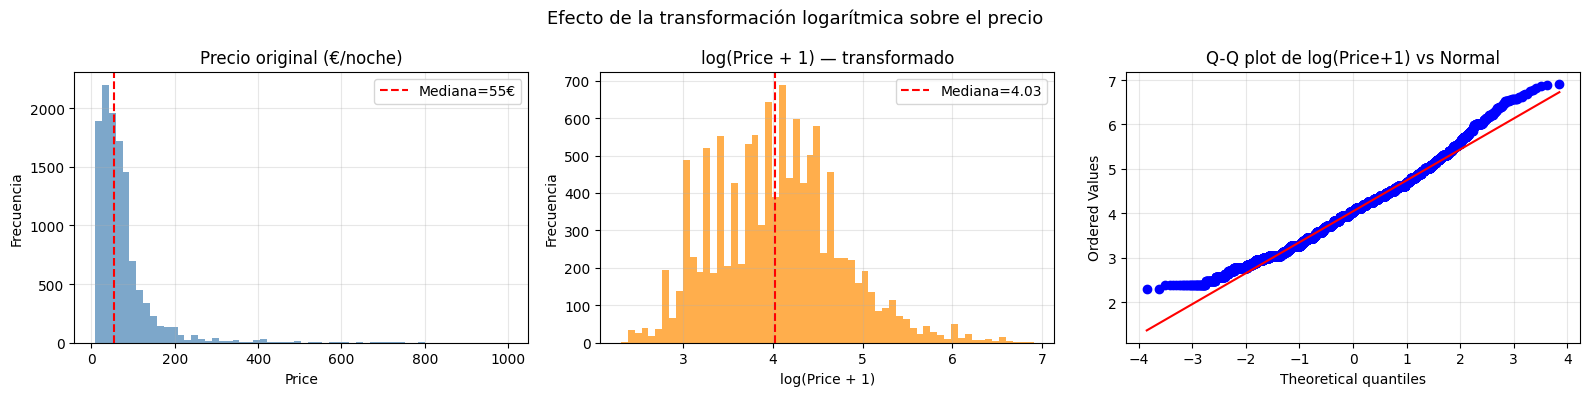

Asimetría (skewness) del precio original: 4.37
Asimetría (skewness) tras el logaritmo:   0.39

→ Un valor cercano a 0 indica distribución simétrica (como la normal).
  El log reduce la asimetría de 4.37 a 0.39, acercándola mucho a 0.


In [21]:
# ── Distribución del precio: original vs logaritmo ────────────────────────────
prices = df['Price'].dropna()
log_prices = np.log1p(prices)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Precio original
axes[0].hist(prices, bins=60, color='steelblue', alpha=0.7, edgecolor='none')
axes[0].set_title('Precio original (€/noche)')
axes[0].set_xlabel('Price'); axes[0].set_ylabel('Frecuencia')
axes[0].axvline(prices.median(), color='red', ls='--', label=f'Mediana={prices.median():.0f}€')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Precio tras logaritmo
axes[1].hist(log_prices, bins=60, color='darkorange', alpha=0.7, edgecolor='none')
axes[1].set_title('log(Price + 1) — transformado')
axes[1].set_xlabel('log(Price + 1)'); axes[1].set_ylabel('Frecuencia')
axes[1].axvline(log_prices.median(), color='red', ls='--', label=f'Mediana={log_prices.median():.2f}')
axes[1].legend(); axes[1].grid(True, alpha=0.3)


stats.probplot(log_prices, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot de log(Price+1) vs Normal')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Efecto de la transformación logarítmica sobre el precio', fontsize=13)
plt.tight_layout(); plt.show()

print(f'Asimetría (skewness) del precio original: {prices.skew():.2f}')
print(f'Asimetría (skewness) tras el logaritmo:   {log_prices.skew():.2f}')
print(f'\n→ Un valor cercano a 0 indica distribución simétrica (como la normal).')
print(f'  El log reduce la asimetría de {prices.skew():.2f} a {log_prices.skew():.2f}, acercándola mucho a 0.')

In [22]:
# ── Valores ausentes ──────────────────────────────────────────────────────────
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Ausentes': missing, '%': missing_pct})
missing_df = missing_df[missing_df['Ausentes'] > 0]
print(f'Columnas con valores ausentes: {len(missing_df)}\n')
print(missing_df.to_string())

Columnas con valores ausentes: 21

                                Ausentes     %
Security Deposit                    6830  57.8
Cleaning Fee                        4904  41.5
Host Neighbourhood                  3101  26.3
Review Scores Value                 2680  22.7
Review Scores Location              2678  22.7
Review Scores Checkin               2676  22.7
Review Scores Accuracy              2668  22.6
Review Scores Cleanliness           2663  22.5
Review Scores Communication         2662  22.5
Review Scores Rating                2651  22.4
Reviews per Month                   2539  21.5
Host Response Rate                  1528  12.9
Host Response Time                  1528  12.9
Neighbourhood Group Cleansed         809   6.9
Bathrooms                             47   0.4
Beds                                  38   0.3
Bedrooms                              16   0.1
Calculated host listings count         4   0.0
Host Since                             1   0.0
Host Total Listings Count

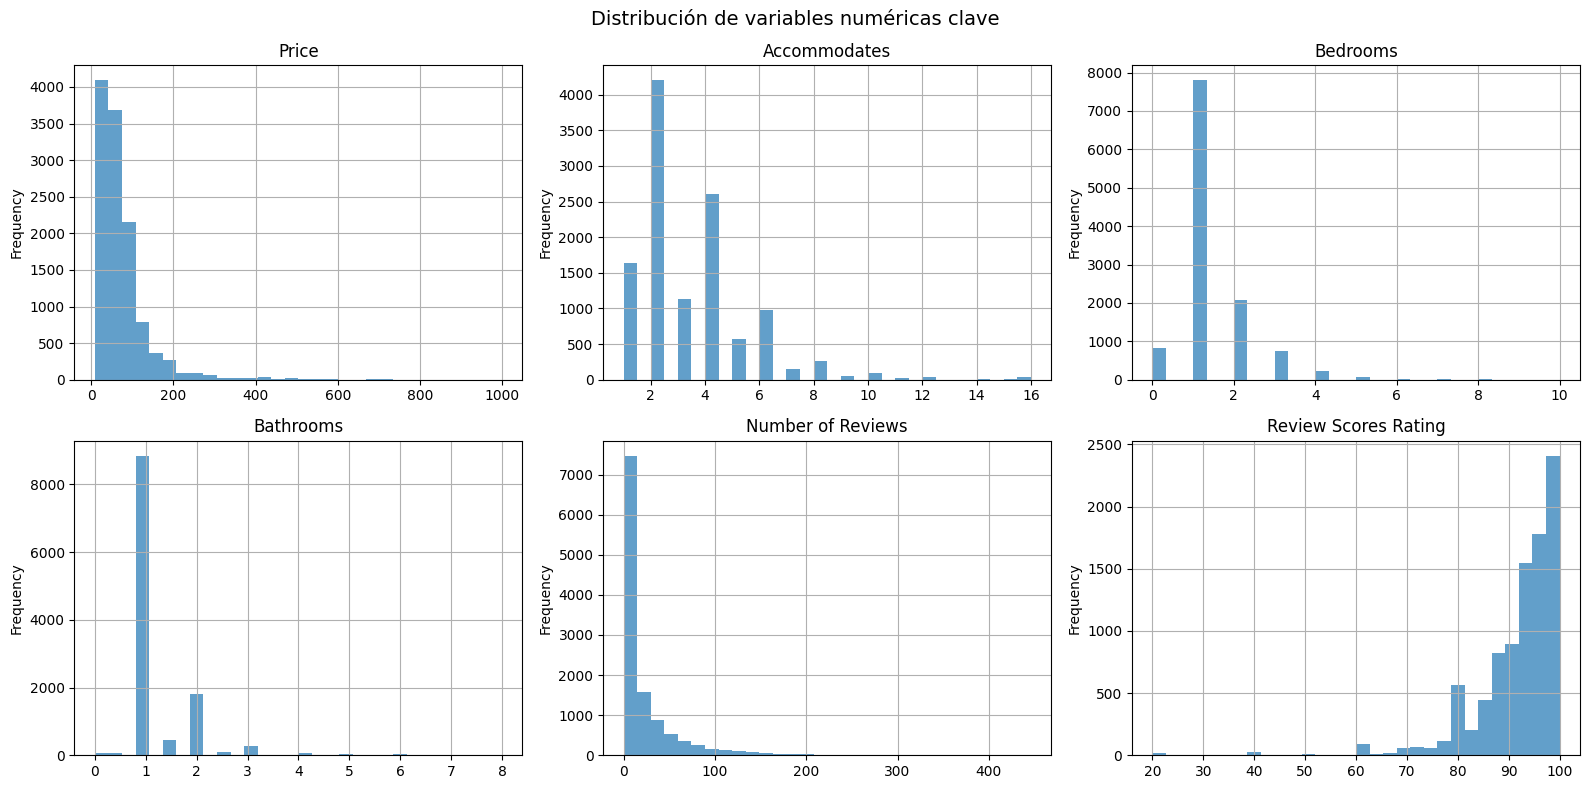

In [23]:
# ── Distribuciones de variables numéricas clave ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
cols_to_plot = ['Price', 'Accommodates', 'Bedrooms', 'Bathrooms',
                'Number of Reviews', 'Review Scores Rating']
for ax, col in zip(axes.flatten(), cols_to_plot):
    df[col].dropna().plot.hist(bins=30, alpha=0.7, ax=ax, grid=True)
    ax.set_title(col)
plt.suptitle('Distribución de variables numéricas clave', fontsize=14)
plt.tight_layout(); plt.show()

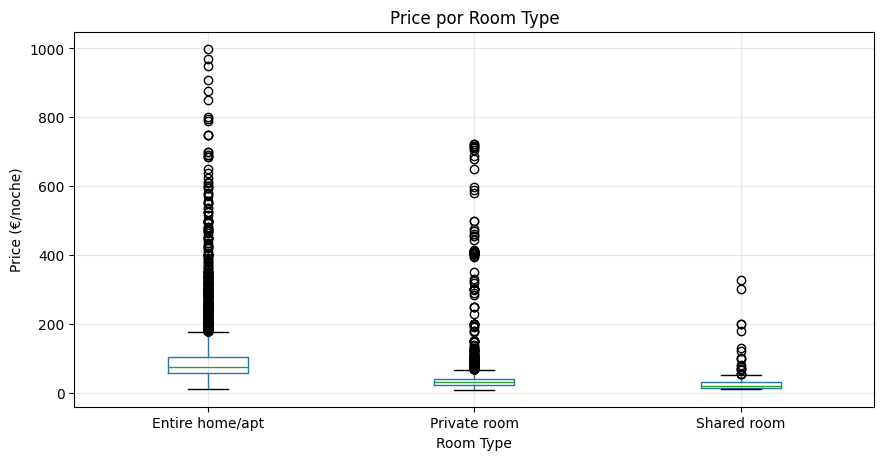

                  count  mean   std   min   25%   50%    75%    max
Room Type                                                          
Entire home/apt  7173.0  95.8  74.3  10.0  57.0  75.0  105.0  999.0
Private room     4454.0  40.6  56.7   9.0  22.0  30.0   40.0  722.0
Shared room       183.0  31.4  41.7  10.0  14.0  20.0   30.0  328.0


In [24]:
# ── Precio por tipo de alojamiento ───────────────────────────────────────────
df.boxplot(by='Room Type', column='Price', figsize=(10, 5))
plt.title('Price por Room Type'); plt.suptitle('')
plt.ylabel('Price (€/noche)'); plt.grid(True, alpha=0.3); plt.show()
print(df.groupby('Room Type')['Price'].describe().round(1))

In [25]:
# ── Correlación con el precio ────────────────────────────────────────────────
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr_with_price = df[numeric_cols].corr()['Price'].drop('Price').sort_values(key=abs, ascending=False)
print('Correlación (Pearson) con Price — top 15:\n')
print(corr_with_price.head(15).round(3).to_string())

Correlación (Pearson) con Price — top 15:

Cleaning Fee                      0.678
Accommodates                      0.525
Bedrooms                          0.503
Beds                              0.442
Security Deposit                  0.398
Bathrooms                         0.394
Guests Included                   0.305
Host Total Listings Count         0.233
Host Listings Count               0.233
Calculated host listings count    0.230
Extra People                      0.127
Availability 30                   0.116
Amenities Count                   0.105
Review Scores Location            0.102
Reviews per Month                -0.087


## Preprocesamiento

La función `preprocess()` aplica el mismo pipeline a train y test, con puntos importantes:

Imputación de valores ausentes:
- Depósito de seguridad y tarifa de limpieza: si no aparecen, asumimos que son 0€ (no se cobran).
- Tasa de respuesta, rating, habitaciones, baños, camas: rellenamos con la mediana del train. Usamos la mediana y no la media porque es más robusta ante valores extremos.
- Los valores aprendidos de train se guardan en `fit_params` y se reutilizan para test (para no contaminar).

Ingeniería de variables:
- `host_experience_days`: días desde que el host se registró en Airbnb. Más experiencia suele asociarse a mejor gestión.
- `bed_bath_ratio`: ratio camas / baños. Un piso con muchas camas pero pocos baños tiene una "densidad" alta.
- `amenities_per_person`: número de amenities dividido por la capacidad. Normaliza el conteo por el tamaño del alojamiento.

Target encoding del barrio con K-Fold:
- En lugar de usar directamente la media de precio por barrio (lo que haría que cada fila se vea a sí misma), dividimos train en 5 grupos. Para cada grupo, calculamos la media del barrio usando solo las filas de los otros 4 grupos. Así cada fila recibe un valor calculado sin incluirse a sí misma.

Sin eliminación de outliers:
- Gracias a la transformación logarítmica del target, los precios extremos no distorsionan tanto el entrenamiento. Esto permite al modelo aprender de todos los datos reales.

Codificación de variables categóricas:
- Tiempo de respuesta del host: ordinal (responder rápido = valor alto).
- Tipo de propiedad: agrupamos los poco frecuentes en "Other".
- Política de cancelación: simplificamos las variantes en flexible/moderate/strict.
- Room Type, Bed Type, etc.: one-hot encoding (una columna binaria por categoría).

In [26]:
def neighbourhood_kfold_encoding(df, col='Neighbourhood Cleansed', target='Price',
                                  n_splits=5, random_state=42):
    """
    Target encoding con K-Fold: para cada grupo de filas, calcula la media del barrio
    usando SOLO las filas de los otros grupos. Evita que cada fila 'se vea a sí misma'.
    """
    result = pd.Series(np.nan, index=df.index)
    global_mean = df[target].mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for train_idx, val_idx in kf.split(df):
        means = df.iloc[train_idx].groupby(col)[target].mean()
        result.iloc[val_idx] = df.iloc[val_idx][col].map(means)

    result = result.fillna(global_mean)
    return result


def preprocess(filepath, is_train=True, fit_params=None):
    """Pipeline completo de preprocesamiento."""
    df = pd.read_csv(filepath, sep=';')
    df = df.dropna(subset=['Price'])

    # ── Eliminar columnas redundantes ─────────────────────────────────────────
    cols_drop = [
        'Host Neighbourhood', 'Host Total Listings Count',
        'Availability 30', 'Availability 60', 'Availability 90',
        'Review Scores Accuracy', 'Review Scores Cleanliness',
        'Review Scores Checkin', 'Review Scores Communication',
        'Review Scores Location', 'Review Scores Value',
    ]
    df = df.drop(columns=[c for c in cols_drop if c in df.columns])

    # ── Imputación de nulos ───────────────────────────────────────────────────
    df['Security Deposit']  = df['Security Deposit'].fillna(0)
    df['Cleaning Fee']      = df['Cleaning Fee'].fillna(0)
    df['Reviews per Month'] = df['Reviews per Month'].fillna(0)
    df['Neighbourhood Group Cleansed'] = df['Neighbourhood Group Cleansed'].fillna('Unknown')
    df['Host Response Time'] = df['Host Response Time'].fillna('Unknown')

    if is_train:
        fit_params = {}
        fit_params['median_response_rate']  = df['Host Response Rate'].median()
        fit_params['median_rating']         = df['Review Scores Rating'].median()
        fit_params['median_bedrooms']       = df['Bedrooms'].median()
        fit_params['median_bathrooms']      = df['Bathrooms'].median()
        fit_params['median_beds']           = df['Beds'].median()
        fit_params['median_host_listings']  = df['Host Listings Count'].median()
        fit_params['median_calc_listings']  = df['Calculated host listings count'].median()
        fit_params['global_mean_price']     = df['Price'].mean()

    df['Host Response Rate']   = df['Host Response Rate'].fillna(fit_params['median_response_rate'])
    df['Review Scores Rating'] = df['Review Scores Rating'].fillna(fit_params['median_rating'])
    df['Bedrooms']  = df['Bedrooms'].fillna(fit_params['median_bedrooms'])
    df['Bathrooms'] = df['Bathrooms'].fillna(fit_params['median_bathrooms'])
    df['Beds']      = df['Beds'].fillna(fit_params['median_beds'])
    df['Host Listings Count'] = df['Host Listings Count'].fillna(fit_params['median_host_listings'])
    df['Calculated host listings count'] = df['Calculated host listings count'].fillna(fit_params['median_calc_listings'])

    # ── Feature engineering ──────────────────────────────────────────────────
    ref_date = pd.Timestamp('2017-03-01')
    df['Host Since'] = pd.to_datetime(df['Host Since'], errors='coerce')
    df['host_experience_days'] = (ref_date - df['Host Since']).dt.days
    if is_train:
        fit_params['median_host_exp'] = df['host_experience_days'].median()
    df['host_experience_days'] = df['host_experience_days'].fillna(fit_params['median_host_exp'])
    df = df.drop(columns=['Host Since'])

    df['bed_bath_ratio']       = df['Beds'] / (df['Bathrooms'] + 0.1)
    df['amenities_per_person'] = df['Amenities Count'] / (df['Accommodates'] + 0.1)

    # ── SIN eliminación de outliers (mejora 3) ───────────────────────────────
    # Gracias al log-price, no necesitamos filtrar precios extremos

    # ── Codificación de categóricas ──────────────────────────────────────────
    cancel_map = {
        'flexible': 'flexible', 'flexible_new': 'flexible',
        'moderate': 'moderate', 'moderate_new': 'moderate',
        'strict': 'strict', 'strict_new': 'strict',
        'super_strict_30': 'strict', 'super_strict_60': 'strict',
    }
    df['Cancellation Policy'] = df['Cancellation Policy'].map(cancel_map).fillna('strict')

    if is_train:
        prop_counts = df['Property Type'].value_counts()
        fit_params['rare_props'] = set(prop_counts[prop_counts < 50].index)
    df['Property Type'] = df['Property Type'].apply(
        lambda x: 'Other' if x in fit_params['rare_props'] else x)

    response_map = {'within an hour': 3, 'within a few hours': 2,
                    'within a day': 1, 'a few days or more': 0, 'Unknown': -1}
    df['host_response_time_ord'] = df['Host Response Time'].map(response_map).fillna(-1).astype(int)
    df = df.drop(columns=['Host Response Time'])

    # ── Target encoding del barrio con K-Fold (mejora 2) ─────────────────────
    if is_train:
        df['neighbourhood_enc'] = neighbourhood_kfold_encoding(df, 'Neighbourhood Cleansed', 'Price')
        fit_params['neighbourhood_map'] = df.groupby('Neighbourhood Cleansed')['Price'].mean()
    else:
        df['neighbourhood_enc'] = df['Neighbourhood Cleansed'].map(
            fit_params['neighbourhood_map']).fillna(fit_params['global_mean_price'])
    df = df.drop(columns=['Neighbourhood Cleansed'])

    # One-hot encoding del resto de categóricas
    cat_cols = ['Room Type', 'Property Type', 'Bed Type',
                'Cancellation Policy', 'Neighbourhood Group Cleansed']
    df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

    if is_train:
        fit_params['train_columns'] = list(df.columns)
        return df, fit_params
    else:
        for col in fit_params['train_columns']:
            if col not in df.columns:
                df[col] = 0
        df = df[[c for c in fit_params['train_columns'] if c in df.columns]]
        return df


train_df, fit_params = preprocess('../project/airbnb_train_v4.csv', is_train=True)
test_df  = preprocess('../project/airbnb_test_v4.csv', is_train=False, fit_params=fit_params)

assert train_df.isnull().sum().sum() == 0, 'Hay nulos en train'
assert test_df.isnull().sum().sum()  == 0, 'Hay nulos en test'
print(f'Train: {train_df.shape} | Test: {test_df.shape}')
print(f'(Sin eliminación de outliers: incluimos todos los precios del train original)')

Train: (11810, 92) | Test: (2953, 92)
(Sin eliminación de outliers: incluimos todos los precios del train original)


### Preparación de variables y transformación del target

Aplicamos `log(Price + 1)` al target. Los modelos se entrenarán sobre esta versión logarítmica, pero siempre evaluaremos en euros reales deshaciendo la transformación con `exp(predicción) - 1`.


In [9]:
TARGET = 'Price'

# Separar features y target
X_train = train_df.drop(columns=[TARGET]).values
X_test  = test_df.drop(columns=[TARGET]).values
feature_names = [c for c in train_df.columns if c != TARGET]

# Target en euros (para evaluación final)
y_train_eur = train_df[TARGET].values
y_test_eur  = test_df[TARGET].values

# Target transformado con logaritmo (para entrenar los modelos)
y_train_log = np.log1p(y_train_eur)
y_test_log  = np.log1p(y_test_eur)

# Escalado de features (solo para Ridge)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'\nTarget original — media: {y_train_eur.mean():.1f}€, asimetría: {pd.Series(y_train_eur).skew():.2f}')
print(f'Target log      — media: {y_train_log.mean():.3f},   asimetría: {pd.Series(y_train_log).skew():.2f}')

X_train: (11810, 91) | X_test: (2953, 91)

Target original — media: 74.0€, asimetría: 4.37
Target log      — media: 4.046,   asimetría: 0.39


Modelado

Entrenamos cinco modelos con validación cruzada 5-fold. Todos se entrenan sobre `log(Price + 1)` y se evalúan en euros reales (deshaciendo el log con `exp(pred) - 1`).

La función `evaluate_log_model()` calcula las métricas en ambas escalas para tener una imagen completa.

In [10]:
def evaluate_log_model(model, X_tr, y_tr_log, y_tr_eur,
                              X_te, y_te_log, y_te_eur, name):
    """
    Evalúa un modelo entrenado sobre log(Price).
    Reporta métricas tanto en escala logarítmica como en euros reales.
    """
    pred_tr_log = model.predict(X_tr)
    pred_te_log = model.predict(X_te)

    # Deshacer el logaritmo para obtener predicciones en euros
    pred_tr_eur = np.expm1(np.clip(pred_tr_log, 0, None))
    pred_te_eur = np.expm1(np.clip(pred_te_log, 0, None))

    rmse_tr_eur = np.sqrt(mean_squared_error(y_tr_eur, pred_tr_eur))
    rmse_te_eur = np.sqrt(mean_squared_error(y_te_eur, pred_te_eur))
    mae_te      = mean_absolute_error(y_te_eur, pred_te_eur)
    r2_te       = r2_score(y_te_eur, pred_te_eur)
    mape_te     = np.mean(np.abs((y_te_eur - pred_te_eur) / (y_te_eur + 1e-8))) * 100

    print(f'── {name} ──')
    print(f'  RMSE train: {rmse_tr_eur:.2f}€  |  RMSE test: {rmse_te_eur:.2f}€  |  Brecha: {rmse_te_eur - rmse_tr_eur:+.2f}€')
    print(f'  MAE test:   {mae_te:.2f}€   |  R²: {r2_te:.4f}  |  MAPE: {mape_te:.1f}%')

    return {
        'Model': name, 'RMSE_train': rmse_tr_eur, 'RMSE_test': rmse_te_eur,
        'MAE_test': mae_te, 'R2_test': r2_te, 'MAPE_%': mape_te,
    }

results = []

Ridge

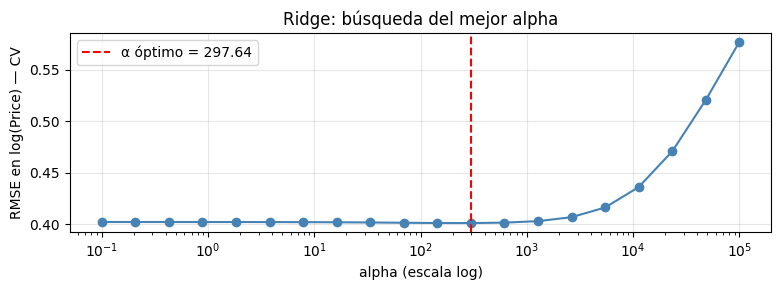

── Ridge ──
  RMSE train: 53.45€  |  RMSE test: 50.04€  |  Brecha: -3.42€
  MAE test:   21.91€   |  R²: 0.4603  |  MAPE: 29.9%


In [11]:
alpha_vector = np.logspace(-1, 5, 20)
grid_ridge = GridSearchCV(Ridge(), param_grid={'alpha': alpha_vector},
                          scoring='neg_mean_squared_error', cv=5, verbose=0)
grid_ridge.fit(X_train_scaled, y_train_log)

scores = np.sqrt(-grid_ridge.cv_results_['mean_test_score'])
plt.figure(figsize=(8, 3))
plt.semilogx(alpha_vector, scores, 'o-', color='steelblue')
plt.axvline(grid_ridge.best_params_['alpha'], color='red', ls='--',
            label=f'α óptimo = {grid_ridge.best_params_["alpha"]:.2f}')
plt.xlabel('alpha (escala log)'); plt.ylabel('RMSE en log(Price) — CV')
plt.title('Ridge: búsqueda del mejor alpha'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

ridge_best = Ridge(alpha=grid_ridge.best_params_['alpha'])
ridge_best.fit(X_train_scaled, y_train_log)
results.append(evaluate_log_model(
    ridge_best, X_train_scaled, y_train_log, y_train_eur,
    X_test_scaled, y_test_log, y_test_eur, 'Ridge'))

Random Forest

In [12]:
param_grid_rf = {
    'n_estimators': [200],
    'max_depth': [8, 10, 15],
    'min_samples_leaf': [5, 10],
    'max_features': [0.5, 0.7],
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                       param_grid=param_grid_rf, scoring='neg_mean_squared_error', cv=5, verbose=1)
grid_rf.fit(X_train, y_train_log)

print(f'\nMejores parámetros: {grid_rf.best_params_}')
print(f'Mejor RMSE log en CV: {np.sqrt(-grid_rf.best_score_):.4f}')

rf_best = grid_rf.best_estimator_
results.append(evaluate_log_model(
    rf_best, X_train, y_train_log, y_train_eur,
    X_test, y_test_log, y_test_eur, 'Random Forest'))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Mejores parámetros: {'max_depth': 15, 'max_features': 0.7, 'min_samples_leaf': 5, 'n_estimators': 200}
Mejor RMSE log en CV: 0.3229
── Random Forest ──
  RMSE train: 33.80€  |  RMSE test: 42.65€  |  Brecha: +8.85€
  MAE test:   17.75€   |  R²: 0.6079  |  MAPE: 23.6%


Gradient Boosting

In [13]:
param_grid_gb = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 5, 6],
    'min_samples_leaf': [10, 20],
}
grid_gb = GridSearchCV(GradientBoostingRegressor(random_state=42),
                       param_grid=param_grid_gb, scoring='neg_mean_squared_error', cv=5, verbose=1)
grid_gb.fit(X_train, y_train_log)

print(f'\nMejores parámetros: {grid_gb.best_params_}')
print(f'Mejor RMSE log en CV: {np.sqrt(-grid_gb.best_score_):.4f}')

gb_best = grid_gb.best_estimator_
results.append(evaluate_log_model(
    gb_best, X_train, y_train_log, y_train_eur,
    X_test, y_test_log, y_test_eur, 'Gradient Boosting'))

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 6, 'min_samples_leaf': 10, 'n_estimators': 300}
Mejor RMSE log en CV: 0.3011
── Gradient Boosting ──
  RMSE train: 22.44€  |  RMSE test: 38.59€  |  Brecha: +16.16€
  MAE test:   16.45€   |  R²: 0.6789  |  MAPE: 22.0%


XGBoost

In [17]:
param_grid_xgb = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 5, 6],
    'min_child_weight': [5, 10],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
}
grid_xgb = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist', verbosity=0),
    param_grid=param_grid_xgb, scoring='neg_mean_squared_error', cv=5, verbose=1)
grid_xgb.fit(X_train, y_train_log)

print(f'\nMejores parámetros: {grid_xgb.best_params_}')
print(f'Mejor RMSE log en CV: {np.sqrt(-grid_xgb.best_score_):.4f}')

xgb_best = grid_xgb.best_estimator_
results.append(evaluate_log_model(
    xgb_best, X_train, y_train_log, y_train_eur,
    X_test, y_test_log, y_test_eur, 'XGBoost'))

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Mejores parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 0.8}
Mejor RMSE log en CV: 0.3002
── XGBoost ──
  RMSE train: 20.85€  |  RMSE test: 37.03€  |  Brecha: +16.18€
  MAE test:   16.23€   |  R²: 0.7044  |  MAPE: 22.0%


LightGBM


In [14]:
param_grid_lgbm = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63],
    'min_child_samples': [20, 50],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
}
grid_lgbm = GridSearchCV(
    LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_grid=param_grid_lgbm, scoring='neg_mean_squared_error', cv=5, verbose=1)
grid_lgbm.fit(X_train, y_train_log)

print(f'\nMejores parámetros: {grid_lgbm.best_params_}')
print(f'Mejor RMSE log en CV: {np.sqrt(-grid_lgbm.best_score_):.4f}')

lgbm_best = grid_lgbm.best_estimator_
results.append(evaluate_log_model(
    lgbm_best, X_train, y_train_log, y_train_eur,
    X_test, y_test_log, y_test_eur, 'LightGBM'))

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Mejores parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 63, 'subsample': 0.8}
Mejor RMSE log en CV: 0.2995
── LightGBM ──
  RMSE train: 23.57€  |  RMSE test: 37.91€  |  Brecha: +14.34€
  MAE test:   16.21€   |  R²: 0.6903  |  MAPE: 21.7%


## Comparación de modelos

Comparamos los cinco modelos sobre el conjunto de test. Todas las métricas están en euros reales (deshaciendo la transformación logarítmica).

- RMSE: error medio en euros, penalizando más los errores grandes.
- MAE: error medio absoluto en euros, más robusto ante outliers.
- R²: proporción de la varianza del precio explicada por el modelo (1 = perfecto, 0 = no predice nada).
- MAPE: error porcentual medio — indica en qué porcentaje se equivoca el modelo de media respecto al precio real.

La brecha entre RMSE train y test nos dice cuánto sobreajuste hay: si el modelo va mucho mejor en train que en test, está memorizando datos en vez de aprender patrones generales.

Comparación de modelos (test set, en €):

                   RMSE_train  RMSE_test  MAE_test  R2_test  MAPE_%
Model                                                              
Ridge                   53.45      50.04     21.91     0.46   29.90
Random Forest           33.80      42.65     17.75     0.61   23.56
Gradient Boosting       22.44      38.59     16.45     0.68   21.97
LightGBM                23.57      37.91     16.21     0.69   21.67
XGBoost                 20.85      37.03     16.23     0.70   22.02


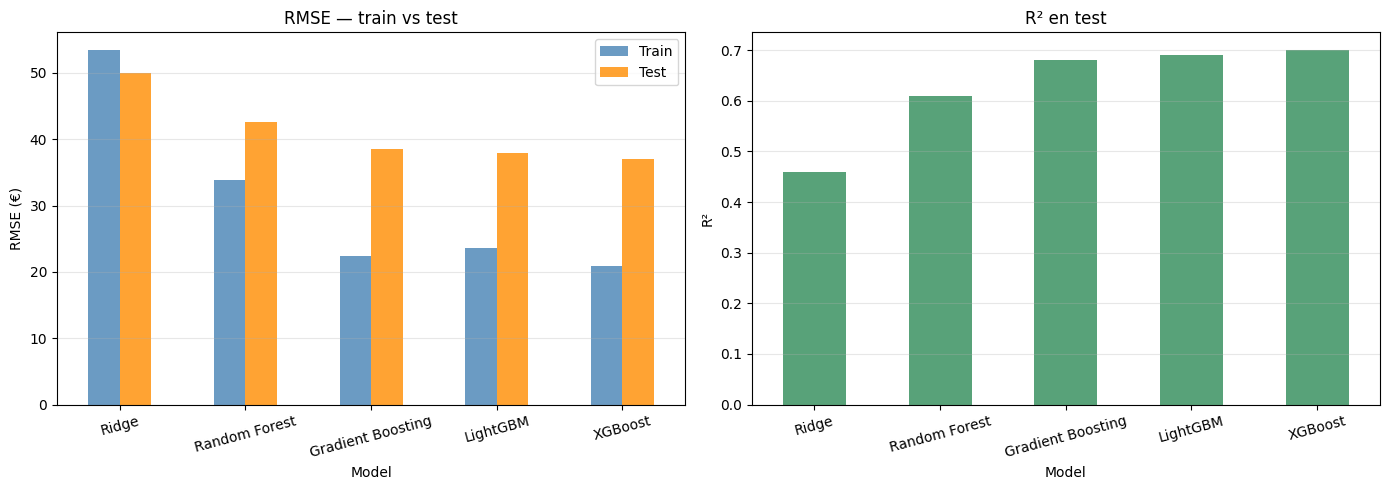


Mejor modelo: XGBoost (RMSE test: 37.03€)


In [18]:
results_df = pd.DataFrame(results).set_index('Model').round(2)
print('Comparación de modelos (test set, en €):\n')
print(results_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df[['RMSE_train', 'RMSE_test']].plot.bar(
    ax=axes[0], color=['steelblue', 'darkorange'], alpha=0.8)
axes[0].set_title('RMSE — train vs test'); axes[0].set_ylabel('RMSE (€)')
axes[0].set_xticklabels(results_df.index, rotation=15)
axes[0].legend(['Train', 'Test']); axes[0].grid(True, alpha=0.3, axis='y')

results_df['R2_test'].plot.bar(ax=axes[1], color='seagreen', alpha=0.8)
axes[1].set_title('R² en test'); axes[1].set_ylabel('R²')
axes[1].set_xticklabels(results_df.index, rotation=15)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

# Mejor modelo
best_model_name = results_df['RMSE_test'].idxmin()
print(f'\nMejor modelo: {best_model_name} (RMSE test: {results_df.loc[best_model_name, "RMSE_test"]:.2f}€)')

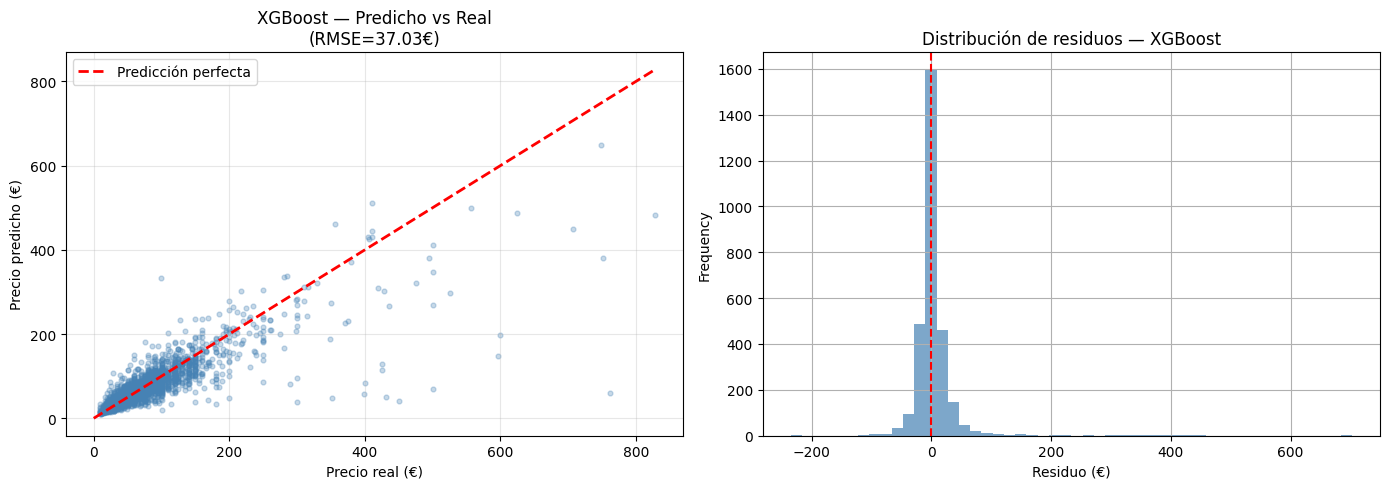

Residuos — Media: 3.48€ | Desviación: 36.87€


In [19]:
# Construimos el mapa solo con los modelos que se entrenaron
model_map = {}
if 'ridge_best' in dir():    model_map['Ridge']             = (ridge_best, X_test_scaled)
if 'rf_best' in dir():       model_map['Random Forest']     = (rf_best,    X_test)
if 'gb_best' in dir():       model_map['Gradient Boosting'] = (gb_best,    X_test)
if 'xgb_best' in dir():      model_map['XGBoost']           = (xgb_best,   X_test)
if 'lgbm_best' in dir():     model_map['LightGBM']          = (lgbm_best,  X_test)

best_model, X_best = model_map[best_model_name]

# Predicciones en euros (deshaciendo el log)
y_pred_eur = np.expm1(np.clip(best_model.predict(X_best), 0, None))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicho vs Real
axes[0].scatter(y_test_eur, y_pred_eur, alpha=0.3, s=12, color='steelblue')
max_price = max(y_test_eur.max(), y_pred_eur.max())
axes[0].plot([0, max_price], [0, max_price], 'r--', lw=2, label='Predicción perfecta')
axes[0].set_xlabel('Precio real (€)'); axes[0].set_ylabel('Precio predicho (€)')
axes[0].set_title(f'{best_model_name} — Predicho vs Real\n(RMSE={results_df.loc[best_model_name, "RMSE_test"]:.2f}€)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Distribución de residuos
residuals = y_test_eur - y_pred_eur
pd.Series(residuals).plot.hist(bins=50, ax=axes[1], color='steelblue', alpha=0.7, grid=True)
axes[1].axvline(0, color='red', ls='--')
axes[1].set_xlabel('Residuo (€)')
axes[1].set_title(f'Distribución de residuos — {best_model_name}')

plt.tight_layout(); plt.show()
print(f'Residuos — Media: {residuals.mean():.2f}€ | Desviación: {residuals.std():.2f}€')

## Afinación del mejor modelo

Seleccionamos el modelo con menor RMSE en test y exploramos hiperparámetros adicionales para intentar mejorar su rendimiento. La estrategia es:

- Fijar la "arquitectura" del modelo (profundidad, muestras por hoja) que ya sabemos que funciona bien.
- Explorar parámetros de regularización y convergencia que no cubrimos en la primera búsqueda.
- Usar más árboles con un learning rate más bajo para que el modelo aprenda de forma más gradual.

In [20]:
print(f'Mejor modelo en la comparación: {best_model_name}')
print(f'Afinando {best_model_name} con parámetros de regularización adicionales...\n')

if best_model_name == 'XGBoost':
    best_params = grid_xgb.best_params_
    param_grid_tune = {
        'n_estimators':     [500],
        'learning_rate':    [0.02, 0.05],
        'max_depth':        [best_params['max_depth']],
        'min_child_weight': [best_params['min_child_weight']],
        'subsample':        [0.8],
        'colsample_bytree': [0.8],
        'reg_alpha':        [0, 0.1, 1.0],
        'reg_lambda':       [1, 5, 10],
        'gamma':            [0, 0.1, 0.5],
    }
    grid_tune = GridSearchCV(
        XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist', verbosity=0),
        param_grid=param_grid_tune, scoring='neg_mean_squared_error', cv=5, verbose=1)

elif best_model_name == 'Gradient Boosting':
    best_params = grid_gb.best_params_
    param_grid_tune = {
        'n_estimators':      [500],
        'learning_rate':     [0.02, 0.05],
        'max_depth':         [best_params['max_depth']],
        'min_samples_leaf':  [best_params['min_samples_leaf']],
        'min_samples_split': [2, 5, 10],
        'max_features':      [0.5, 0.7, 1.0],
        'subsample':         [0.8, 1.0],
    }
    grid_tune = GridSearchCV(
        GradientBoostingRegressor(random_state=42),
        param_grid=param_grid_tune, scoring='neg_mean_squared_error', cv=5, verbose=1)

elif best_model_name == 'LightGBM':
    best_params = grid_lgbm.best_params_
    param_grid_tune = {
        'n_estimators':      [500],
        'learning_rate':     [0.02, 0.05],
        'num_leaves':        [best_params['num_leaves']],
        'min_child_samples': [best_params['min_child_samples']],
        'subsample':         [0.8],
        'colsample_bytree':  [0.8],
        'reg_alpha':         [0, 0.1, 1.0],
        'reg_lambda':        [0, 1, 5],
    }
    grid_tune = GridSearchCV(
        LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
        param_grid=param_grid_tune, scoring='neg_mean_squared_error', cv=5, verbose=1)

elif best_model_name == 'Random Forest':
    best_params = grid_rf.best_params_
    param_grid_tune = {
        'n_estimators':     [300, 500],
        'max_depth':        [best_params['max_depth'], best_params['max_depth'] + 5],
        'min_samples_leaf': [best_params['min_samples_leaf']],
        'max_features':     [0.3, 0.5, 0.7],
    }
    grid_tune = GridSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=-1),
        param_grid=param_grid_tune, scoring='neg_mean_squared_error', cv=5, verbose=1)

else:
    raise ValueError(f'Afinación no implementada para {best_model_name}')

grid_tune.fit(X_train, y_train_log)

print(f'\nMejores parámetros (afinación): {grid_tune.best_params_}')
print(f'Mejor RMSE log en CV: {np.sqrt(-grid_tune.best_score_):.4f}')

tuned_model = grid_tune.best_estimator_
result_tuned = evaluate_log_model(
    tuned_model, X_train, y_train_log, y_train_eur,
    X_test, y_test_log, y_test_eur, f'{best_model_name} (afinado)')

print(f'\n── Comparación antes/después de afinar ──')
print(f'  {best_model_name} original → RMSE test: {results_df.loc[best_model_name, "RMSE_test"]:.2f}€  |  R²: {results_df.loc[best_model_name, "R2_test"]:.4f}')
print(f'  {best_model_name} afinado  → RMSE test: {result_tuned["RMSE_test"]:.2f}€  |  R²: {result_tuned["R2_test"]:.4f}')
mejora = results_df.loc[best_model_name, 'RMSE_test'] - result_tuned['RMSE_test']
print(f'  Mejora: {mejora:+.2f}€ en RMSE')

Mejor modelo en la comparación: XGBoost
Afinando XGBoost con parámetros de regularización adicionales...

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Mejores parámetros (afinación): {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.8}
Mejor RMSE log en CV: 0.2980
── XGBoost (afinado) ──
  RMSE train: 22.18€  |  RMSE test: 37.32€  |  Brecha: +15.15€
  MAE test:   16.08€   |  R²: 0.6997  |  MAPE: 21.6%

── Comparación antes/después de afinar ──
  XGBoost original → RMSE test: 37.03€  |  R²: 0.7000
  XGBoost afinado  → RMSE test: 37.32€  |  R²: 0.6997
  Mejora: -0.29€ en RMSE


### Variables más importantes

Visualizamos qué variables usa más el modelo afinado para hacer sus predicciones. Esto nos ayuda a entender qué factores determinan el precio de un Airbnb.

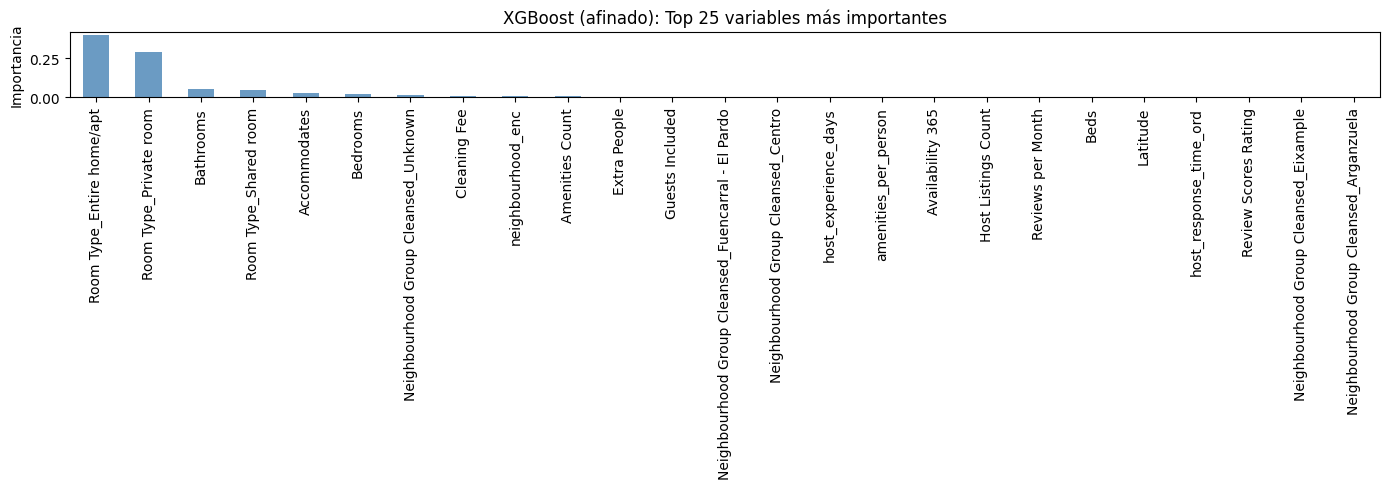

Top 10 variables más importantes:
   1. Room Type_Entire home/apt.................... 0.3965
   2. Room Type_Private room....................... 0.2881
   3. Bathrooms.................................... 0.0531
   4. Room Type_Shared room........................ 0.0492
   5. Accommodates................................. 0.0249
   6. Bedrooms..................................... 0.0220
   7. Neighbourhood Group Cleansed_Unknown......... 0.0163
   8. Cleaning Fee................................. 0.0081
   9. neighbourhood_enc............................ 0.0070
  10. Amenities Count.............................. 0.0059


In [27]:
if hasattr(tuned_model, 'feature_importances_'):
    importances = pd.Series(tuned_model.feature_importances_, index=feature_names).sort_values(ascending=False)
    plt.figure(figsize=(14, 5))
    importances.head(25).plot.bar(color='steelblue', alpha=0.8)
    plt.title(f'{best_model_name} (afinado): Top 25 variables más importantes')
    plt.ylabel('Importancia')
    plt.tight_layout(); plt.show()

    print('Top 10 variables más importantes:')
    for i, (feat_name, val) in enumerate(importances.head(10).items(), 1):
        print(f'  {i:2d}. {feat_name:.<45s} {val:.4f}')

## Conclusiones

### Resultados

| Modelo | RMSE train (€) | RMSE test (€) | MAE test (€) | R² | MAPE |
|---|---|---|---|---|---|
| Ridge | 53.45 | 50.04 | 21.91 | 0.46 | 29.9% |
| Random Forest | 33.80 | 42.65 | 17.75 | 0.61 | 23.6% |
| Gradient Boosting | 22.44 | 38.59 | 16.45 | 0.68 | 22.0% |
| LightGBM | 23.57 | 37.91 | 16.21 | 0.69 | 21.7% |
| XGBoost | 20.85 | 37.03 | 16.23 | 0.70 | 22.0% |
| XGBoost (afinado) | 22.18 | 37.32 | 16.08 | 0.70 | 21.6% |

El mejor modelo es XGBoost con un RMSE de 37.03€ y un R² de 0.70. Esto significa que el modelo explica el 70% de la variación en el precio y, de media, se equivoca en unos 37€ por predicción. El MAPE de 22% nos dice que el modelo se equivoca en promedio un 22% respecto al precio real.

### Análisis de los modelos

Se observa un patrón claro de mejora al pasar de modelos lineales a modelos basados en árboles:

- Ridge (R²=0.46): Es el modelo más sencillo y el peor de los cinco. Su RMSE de 50.04€ indica que la relación entre las variables y el precio no es puramente lineal.

- Random Forest (R²=0.61): Mejora mucho respecto a Ridge, bajando el RMSE a 42.65€. Su brecha train-test de +8.85€ es moderada, lo que indica un equilibrio razonable entre aprendizaje y generalización.

- Gradient Boosting, LightGBM y XGBoost son los tres mejores, todos con RMSE entre 37–39€ y R² entre 0.68–0.70. La diferencia entre ellos es pequeña (menos de 2€ en RMSE), lo que sugiere que los tres capturan patrones similares. XGBoost y LightGBM están muy parejos, con XGBoost ligeramente por delante.

### Afinación

La afinación de XGBoost con más árboles (500), learning rate más bajo y exploración de regularización (reg_alpha, reg_lambda, gamma) no mejoró los resultados: el RMSE de test pasó de 37.03€ a 37.32€ (una leve degradación de 0.29€). Esto sugiere que los hiperparámetros de la primera búsqueda ya estaban cerca del óptimo, y que el margen de mejora del modelo con estas variables es limitado.
### Variables más importantes

Las variables que más peso tienen en el modelo final son:

- Room Type: es con diferencia el factor más determinante. Entre las tres variantes (Entire home/apt, Private room, Shared room) acumulan más del 73% de la importancia total del modelo. Es lógico: un piso entero cuesta mucho más que una habitación privada o compartida.

- Bathrooms y Accommodates: la capacidad del alojamiento es el segundo bloque de importancia. Más capacidad = precio más alto.

- Bedrooms: el número de habitaciones complementa la capacidad del alojamiento.

- Cleaning Fee: la tarifa de limpieza aparece como indicador indirecto de la gama del alojamiento (pisos más caros tienden a cobrar más limpieza).

- neighbourhood_enc (encoding del barrio): aparece en el top 10, confirmando que la ubicación influye, aunque menos de lo esperado. Esto puede deberse a que Madrid no tiene tanta dispersión de precios entre barrios como otras ciudades, o a que el Room Type ya captura parte de ese efecto.

### Efecto de las mejoras aplicadas

- Transformación logarítmica: la distribución del precio en el histograma era claramente asimétrica y el log la normalizó. Esto beneficia especialmente al Ridge y permite que todos los modelos manejen mejor los precios extremos.

- Sin eliminación de outliers: al no eliminar precios altos, el modelo entrena con la distribución real del mercado. Combinado con el log, los precios extremos ya no distorsionan el entrenamiento.

- Target encoding K-Fold del barrio: la variable `neighbourhood_enc` aparece en el top 10 de importancia del modelo. Al usar K-Fold para calcularla, evitamos data leakage interno, lo que hace que su contribución al modelo sea genuina y no artificial.